In [2]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Carga desde un archivo .csv sin indice
data=pd.read_csv('Principales_Canales_Limpio.csv') 
data

,Mes,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Conversion,Aporte,Canal,Citas Programadas
0,"Febrero, 24",329,0,0,22,4,9,0.027356,0.000000,Piso,9
1,"Marzo, 24",19,0,0,13,16,4,0.210526,0.333333,Piso,28
2,"Abril, 24",76,0,0,35,6,10,0.131579,1.428571,Piso,15
3,"Mayo, 24",87,0,0,40,16,1,0.011494,0.125000,Piso,38
4,"Junio, 24",55,0,0,28,60,3,0.054545,0.230769,Piso,78
...,...,...,...,...,...,...,...,...,...,...,...
85,"Marzo, 26",980,618,16,25,36,11,0.011224,0.366667,Digital,78
86,"Abril, 26",834,179,32,35,59,8,0.009592,0.195122,Digital,83
87,"Mayo, 26",667,170,30,35,103,9,0.013493,0.219512,Digital,140
88,"Junio, 26",748,200,28,28,53,7,0.009358,0.200000,Digital,101


In [4]:
#Verifico la información del DataFrame para identificar las variables numéricas
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Mes                90 non-null     str    
 1   Leads              90 non-null     int64  
 2   Efectivos          90 non-null     int64  
 3   SDC                90 non-null     int64  
 4   PDM                90 non-null     int64  
 5   Citas Efectivas    90 non-null     int64  
 6   Ventas             90 non-null     int64  
 7   Conversion         90 non-null     float64
 8   Aporte             90 non-null     float64
 9   Canal              90 non-null     str    
 10  Citas Programadas  90 non-null     int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 9.3 KB


In [5]:
#Compruebo que la base no tenga valores nulos
valores_nulos = data.isnull().sum()
valores_nulos

Mes                  0
Leads                0
Efectivos            0
SDC                  0
PDM                  0
Citas Efectivas      0
Ventas               0
Conversion           0
Aporte               0
Canal                0
Citas Programadas    0
dtype: int64

In [6]:
#Separo las variables numéricas porque son las que pueden analizarse para detectar outliers
#No significa que todas se modificarán; primero revisaré si los valores extremos son errores o datos válidos
cuantitativas = data.iloc[:, [1,2,3,4,5,6,7,8,10]]

#Separo Mes y Canal porque son variables cualitativas y no corresponde aplicarles cuartiles
cualitativas = data.iloc[:, [0,9]]

In [7]:
#Reviso las variables cuantitativas seleccionadas antes de analizar sus valores atípicos
cuantitativas.describe()

,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Conversion,Aporte,Citas Programadas
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,313.311111,101.177778,17.733333,23.866667,38.066667,6.666667,0.049527,0.254433,56.122222
std,307.655127,156.423767,14.316487,13.189373,26.171775,4.250578,0.060790,0.242964,33.415944
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,71.250000,0.000000,0.000000,15.250000,18.000000,3.000000,0.009417,0.144643,29.250000
50%,204.500000,0.000000,20.000000,25.500000,34.000000,7.000000,0.021511,0.225000,57.500000
75%,425.500000,137.500000,28.000000,33.000000,57.750000,10.000000,0.075760,0.333333,77.750000
max,1353.000000,674.000000,51.000000,48.000000,105.000000,15.000000,0.302326,1.666667,140.000000


In [8]:
#Los rangos muestran diferencias importantes entre algunos valores, principalmente en Leads, Efectivos, Conversión y Aporte
#No los considero errores todavía, ya que pueden representar diferencias entre meses y canales, primero revisaré los outliers con IQR

<Figure size 1500x800 with 0 Axes>

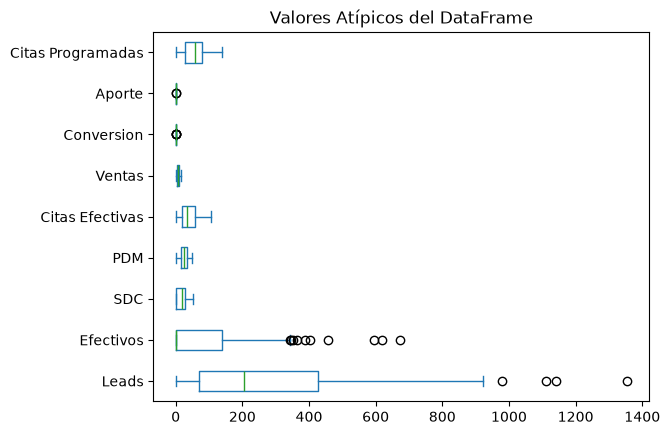

In [9]:
#Realizo un diagrama de caja para observar posibles valores atípicos
fig = plt.figure(figsize=(15,8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del DataFrame")
plt.show()

In [10]:
#El boxplot muestra posibles valores atípicos, principalmente en Leads y Efectivos
#Sin embargo, no los considero errores automáticamente porque pueden representar meses con mayor actividad
#Aplicaré el método de cuartiles para identificarlos y después revisaré los valores antes de modificarlos

In [11]:
#Aplico el método de cuartiles para encontrar los límites de los posibles outliers
y = cuantitativas

percentile25 = y.quantile(0.25) #Q1
percentile75 = y.quantile(0.75) #Q3
iqr = percentile75 - percentile25

Limite_Superior_iqr = percentile75 + 1.5*iqr
Limite_Inferior_iqr = percentile25 - 1.5*iqr

print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Leads                956.875000
Efectivos            343.750000
SDC                   70.000000
PDM                   59.625000
Citas Efectivas      117.375000
Ventas                20.500000
Conversion             0.175274
Aporte                 0.616369
Citas Programadas    150.500000
dtype: float64
Limite inferior permitido Leads               -460.125000
Efectivos           -206.250000
SDC                  -42.000000
PDM                  -11.375000
Citas Efectivas      -41.625000
Ventas                -7.500000
Conversion            -0.090098
Aporte                -0.138393
Citas Programadas    -43.500000
dtype: float64


In [12]:
#Identifico los posibles outliers según los límites obtenidos con cuartiles
#Los convierto temporalmente en nulos para poder revisar cuántos hay en cada variable
data3_iqr = cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Conversion,Aporte,Citas Programadas
0,329.0,0.0,0,22,4,9,0.027356,0.000000,9
1,19.0,0.0,0,13,16,4,NaN,0.333333,28
2,76.0,0.0,0,35,6,10,0.131579,NaN,15
3,87.0,0.0,0,40,16,1,0.011494,0.125000,38
4,55.0,0.0,0,28,60,3,0.054545,0.230769,78
...,...,...,...,...,...,...,...,...,...
85,NaN,NaN,16,25,36,11,0.011224,0.366667,78
86,834.0,179.0,32,35,59,8,0.009592,0.195122,83
87,667.0,170.0,30,35,103,9,0.013493,0.219512,140
88,748.0,200.0,28,28,53,7,0.009358,0.200000,101


In [13]:
#Reviso cuántos posibles outliers fueron detectados en cada variable
valores_nulos = data3_iqr.isnull().sum()
valores_nulos

Leads                 4
Efectivos            10
SDC                   0
PDM                   0
Citas Efectivas       0
Ventas                0
Conversion            4
Aporte                2
Citas Programadas     0
dtype: int64

In [14]:
#Reviso los valores detectados como outliers antes de decidir si necesitan tratamiento
for columna in ["Leads", "Efectivos", "Conversion", "Aporte"]:
    print("\n", columna)
    print(data.loc[data3_iqr[columna].isnull(),
                   ["Mes", "Canal", columna]])


 Leads
               Mes    Canal  Leads
66      Agosto, 24  Digital   1112
67  Septiembre, 24  Digital   1353
68     Octubre, 24  Digital   1142
85       Marzo, 26  Digital    980

 Efectivos
               Mes    Canal  Efectivos
54     Febrero, 26   Plazas        387
55       Marzo, 26   Plazas        364
56       Abril, 26   Plazas        351
57        Mayo, 26   Plazas        347
58       Junio, 26   Plazas        403
79  Septiembre, 25  Digital        344
82   Diciembre, 25  Digital        594
83       Enero, 26  Digital        674
84     Febrero, 26  Digital        457
85       Marzo, 26  Digital        618

 Conversion
              Mes Canal  Conversion
1       Marzo, 24  Piso    0.210526
9   Noviembre, 24  Piso    0.220000
14      Abril, 25  Piso    0.302326
15       Mayo, 25  Piso    0.184615

 Aporte
         Mes Canal    Aporte
2  Abril, 24  Piso  1.428571
5  Julio, 24  Piso  1.666667


In [ ]:
#Los outliers de Leads y Efectivos se concentran principalmente en Digital y Plazas,
#por lo que pueden deberse al comportamiento de cada canal y no necesariamente a errores.
#Antes de modificar Conversion y Aporte revisaré sus valores y su relación con las demás variables.

In [15]:
#Reviso con mayor detalle los casos atípicos de Conversion y Aporte
for columna in ["Conversion", "Aporte"]:
    print("\n", columna)
    print(data.loc[data3_iqr[columna].isnull(),
                   ["Mes", "Canal", "Leads", "Citas Efectivas", "Ventas",
                    "Conversion", "Aporte"]].to_string())


 Conversion
              Mes Canal  Leads  Citas Efectivas  Ventas  Conversion    Aporte
1       Marzo, 24  Piso     19               16       4    0.210526  0.333333
9   Noviembre, 24  Piso     50               14      11    0.220000  0.478261
14      Abril, 25  Piso     43               34      13    0.302326  0.433333
15       Mayo, 25  Piso     65               65      12    0.184615  0.400000

 Aporte
         Mes Canal  Leads  Citas Efectivas  Ventas  Conversion    Aporte
2  Abril, 24  Piso     76                6      10    0.131579  1.428571
5  Julio, 24  Piso     92               57      10    0.108696  1.666667


In [ ]:
#Los valores atípicos de Conversion coinciden con meses donde hubo una proporción mayor de ventas respecto a los leads,
#por lo que se conservan, ya que representan resultados posibles y no errores de captura.

#Los valores de Leads y Efectivos también se conservan porque se concentran en determinados canales y meses,
#lo que puede representar diferencias en su nivel de actividad.

#En Aporte aparecen dos valores mayores a 1, por lo que antes de modificarlos reviso qué representa esta variable
#y cómo fue calculada, ya que no es correcto sustituirlos solo por haber sido detectados como outliers.

In [16]:
#Compruebo que el DataFrame final continúe sin valores nulos
valores_nulos = data.isnull().sum()
valores_nulos

Mes                  0
Leads                0
Efectivos            0
SDC                  0
PDM                  0
Citas Efectivas      0
Ventas               0
Conversion           0
Aporte               0
Canal                0
Citas Programadas    0
dtype: int64

In [17]:
#Compruebo que se conservaron las filas y columnas originales
data.shape

(90, 11)

In [18]:
#Guardo la base después de analizar los valores atípicos
data.to_csv("Principales_Canales_Tratamiento_Outliers.csv", index=False)